In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

df = pd.read_csv('athlete_events.csv')
judo_df = df[df['Sport'] == 'Judo'].copy()

print(f"Dataset Size: {judo_df.shape[0]} rows and {judo_df.shape[1]} columns")

Dataset Size: 3801 rows and 15 columns


In [43]:
judo_df['Weight'] = judo_df['Weight'].fillna(judo_df['Weight'].median())
judo_df['Height'] = judo_df['Height'].fillna(judo_df['Height'].median())
judo_df['Age'] = judo_df['Age'].fillna(judo_df['Age'].median())

print("Missing values filled successfully.")

Missing values filled successfully.


In [61]:
judo_df['BMI'] = judo_df['Weight'] / ((judo_df['Height'] / 100) ** 2)
judo_df['Medal_Won'] = judo_df['Medal'].notna()

display(judo_df[['Name','Sex','Age','Height','Games', 'Weight', 'BMI', 'Medal_Won']])

,Name,Sex,Age,Height,Games,Weight,BMI,Medal_Won
1,A Lamusi,M,23.0,170.0,2012 Summer,60.0,20.761246,False
160,M'Bairo Abakar,M,31.0,174.0,1992 Summer,73.0,24.111507,False
180,Salim Abanoz,M,26.0,174.0,1996 Summer,73.0,24.111507,False
412,Mohamed Ali Abdelaal,M,26.0,175.0,2016 Summer,81.0,26.448980,False
435,Ahmed Abdelrahman,M,20.0,165.0,2016 Summer,60.0,22.038567,False
...,...,...,...,...,...,...,...,...
270853,Oleg Zurabiani,M,19.0,172.0,1976 Summer,64.0,21.633315,False
270918,Goran uvela,M,27.0,184.0,1976 Summer,93.0,27.469282,False
270981,Zurab Zviadauri,M,23.0,182.0,2004 Summer,90.0,27.170632,True
271032,Claudia Antoinette Zwiers,F,22.0,181.0,1996 Summer,78.0,23.808797,True


In [56]:
weight_mapping = { 
    "Judo Men's Extra-Lightweight": "Men -60kg",
    "Judo Men's Half-Lightweight": "Men -66kg",
    "Judo Men's Lightweight": "Men -73kg",
    "Judo Men's Half-Middleweight": "Men -81kg",
    "Judo Men's Middleweight": "Men -90kg",
    "Judo Men's Half-Heavyweight": "Men -100kg",
    "Judo Men's Heavyweight": "Men +100kg",
    "Judo Women's Extra-Lightweight": "Women -48kg",
    "Judo Women's Half-Lightweight": "Women -52kg",
    "Judo Women's Lightweight": "Women -57kg",
    "Judo Women's Half-Middleweight": "Women -63kg",
    "Judo Women's Middleweight": "Women -70kg",
    "Judo Women's Half-Heavyweight": "Women -78kg",
    "Judo Women's Heavyweight": "Women +78kg"
}

judo_df['Weight_Class'] = judo_df['Event'].map(weight_mapping)

medalists_df = judo_df[judo_df['Medal_Won'] == True]

men_medalists = medalists_df[medalists_df['Sex'] == 'M']
women_medalists = medalists_df[medalists_df['Sex'] == 'F']

ideal_bmi_men = men_medalists.groupby('Weight_Class')['BMI'].median().sort_values()
print("Ideal BMI for men's weight classes :")
print(ideal_bmi_men)
print("\n")

ideal_bmi_women = women_medalists.groupby('Weight_Class')['BMI'].median().sort_values()
print("Ideal BMI for women's weight classes :")
print(ideal_bmi_women)

Ideal BMI for men's weight classes :
Weight_Class
Men -60kg     22.585862
Men -66kg     23.384354
Men -73kg     24.111507
Men -81kg     25.000000
Men -90kg     26.686763
Men -100kg    27.908753
Men +100kg    32.545304
Name: BMI, dtype: float64


Ideal BMI for women's weight classes :
Weight_Class
Women -48kg    20.568807
Women -52kg    21.096191
Women -57kg    21.989892
Women -63kg    23.140496
Women -70kg    23.842115
Women -78kg    24.897060
Women +78kg    34.083045
Name: BMI, dtype: float64


In [48]:
medalists_bmi = judo_df[judo_df['Medal_Won'] == True]['BMI']
non_medalists_bmi = judo_df[judo_df['Medal_Won'] == False]['BMI']
t_stat, p_value = stats.ttest_ind(medalists_bmi, non_medalists_bmi)
print(f"Significance Test (BMI vs Medals):")
print(f"T-statistics: {t_stat:.4f}, P-value: {p_value:.5f}\n")

Significance Test (BMI vs Medals):
T-statistics: 3.1902, P-value: 0.00143



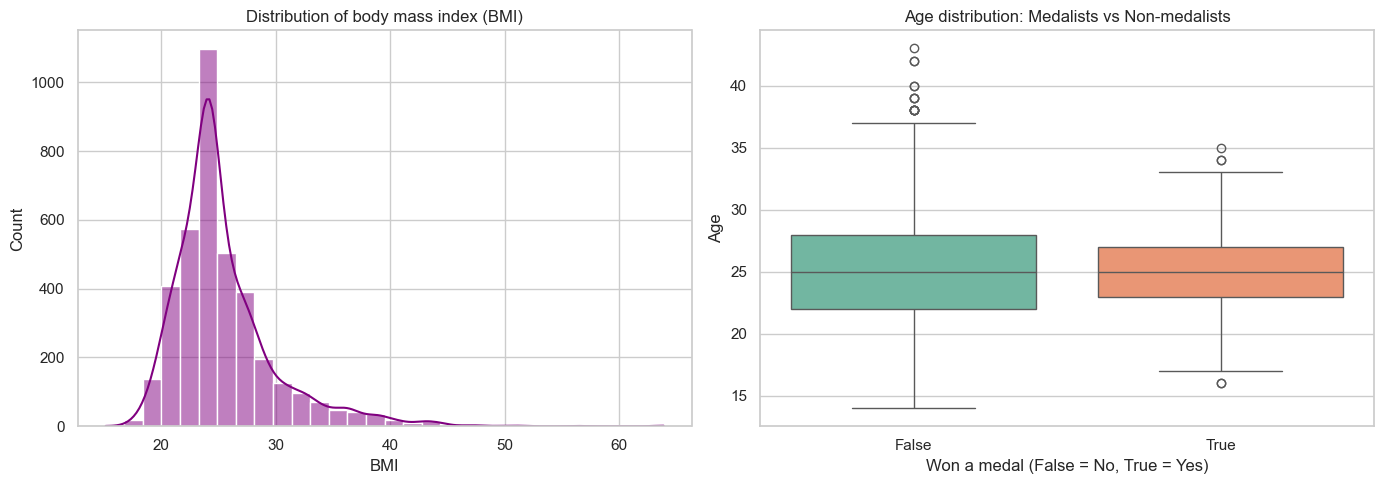

In [57]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(judo_df['BMI'], bins=30, kde=True, color='purple', ax=axes[0])
axes[0].set_title('Distribution of body mass index (BMI)')

sns.boxplot(x='Medal_Won', y='Age', data=judo_df, hue='Medal_Won', palette='Set2', legend=False, ax=axes[1])
axes[1].set_title('Age distribution: Medalists vs Non-medalists')
axes[1].set_xlabel('Won a medal (False = No, True = Yes)')

plt.tight_layout()
plt.show()